<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Superconducting_CPW_Analysis_Cross_Section_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

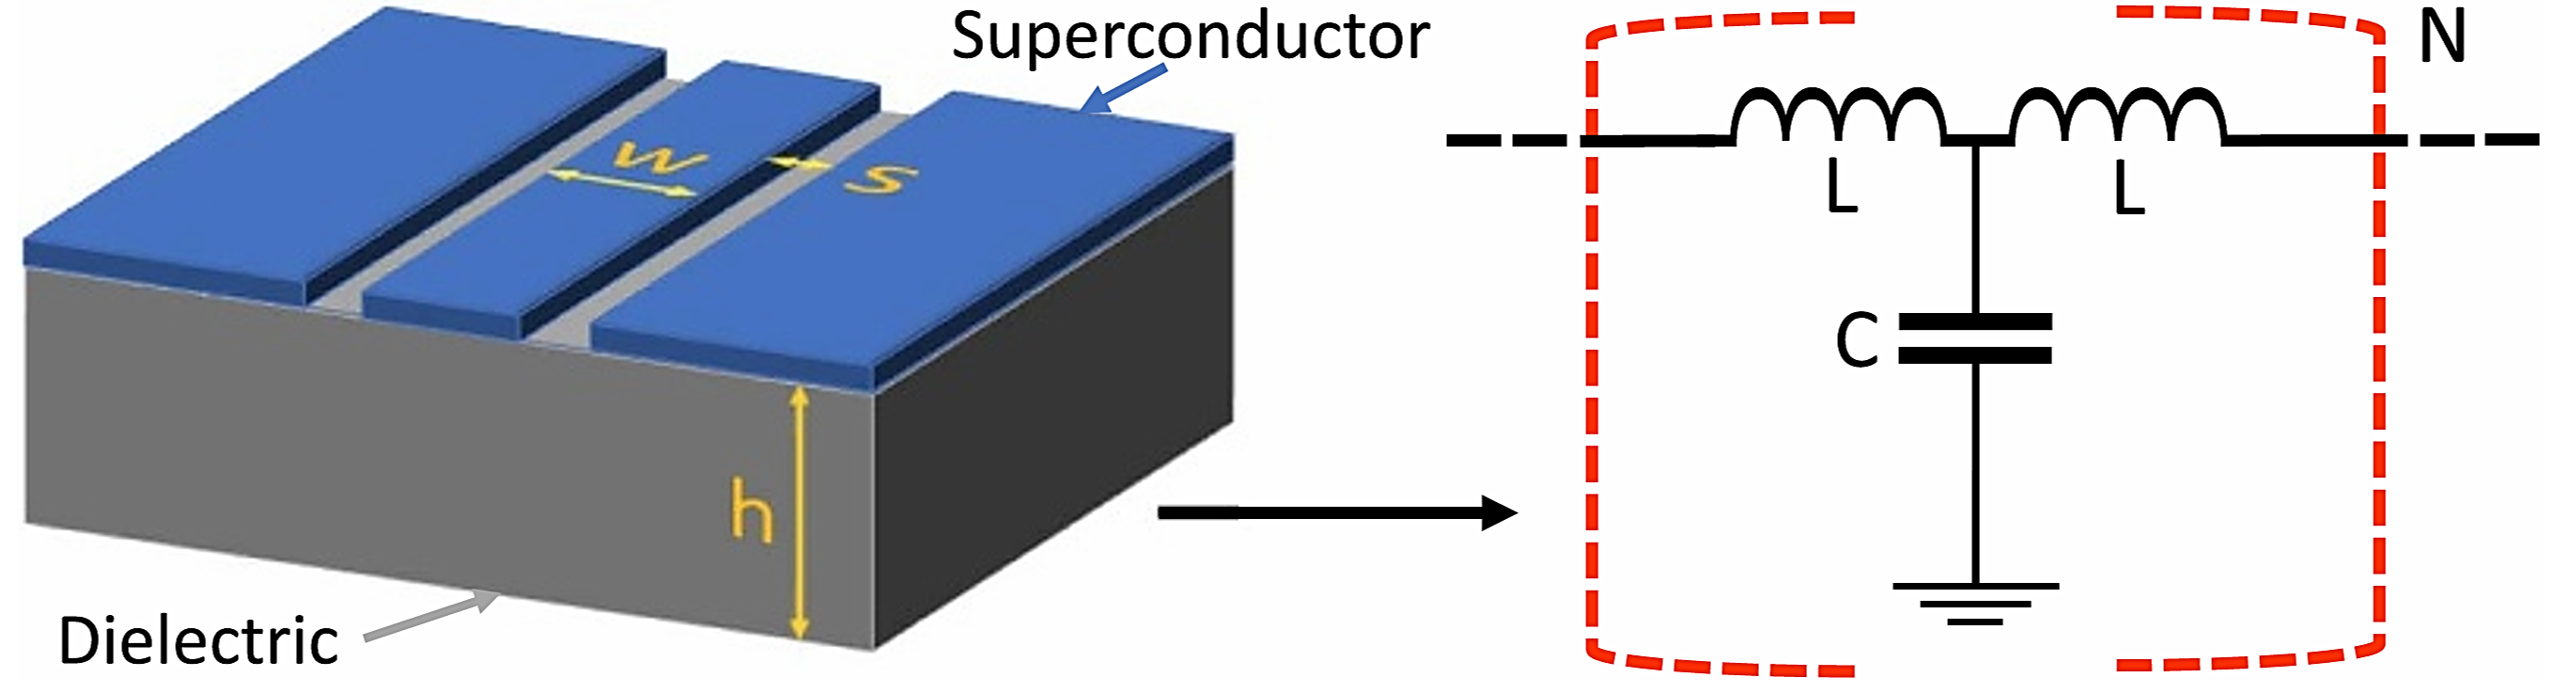

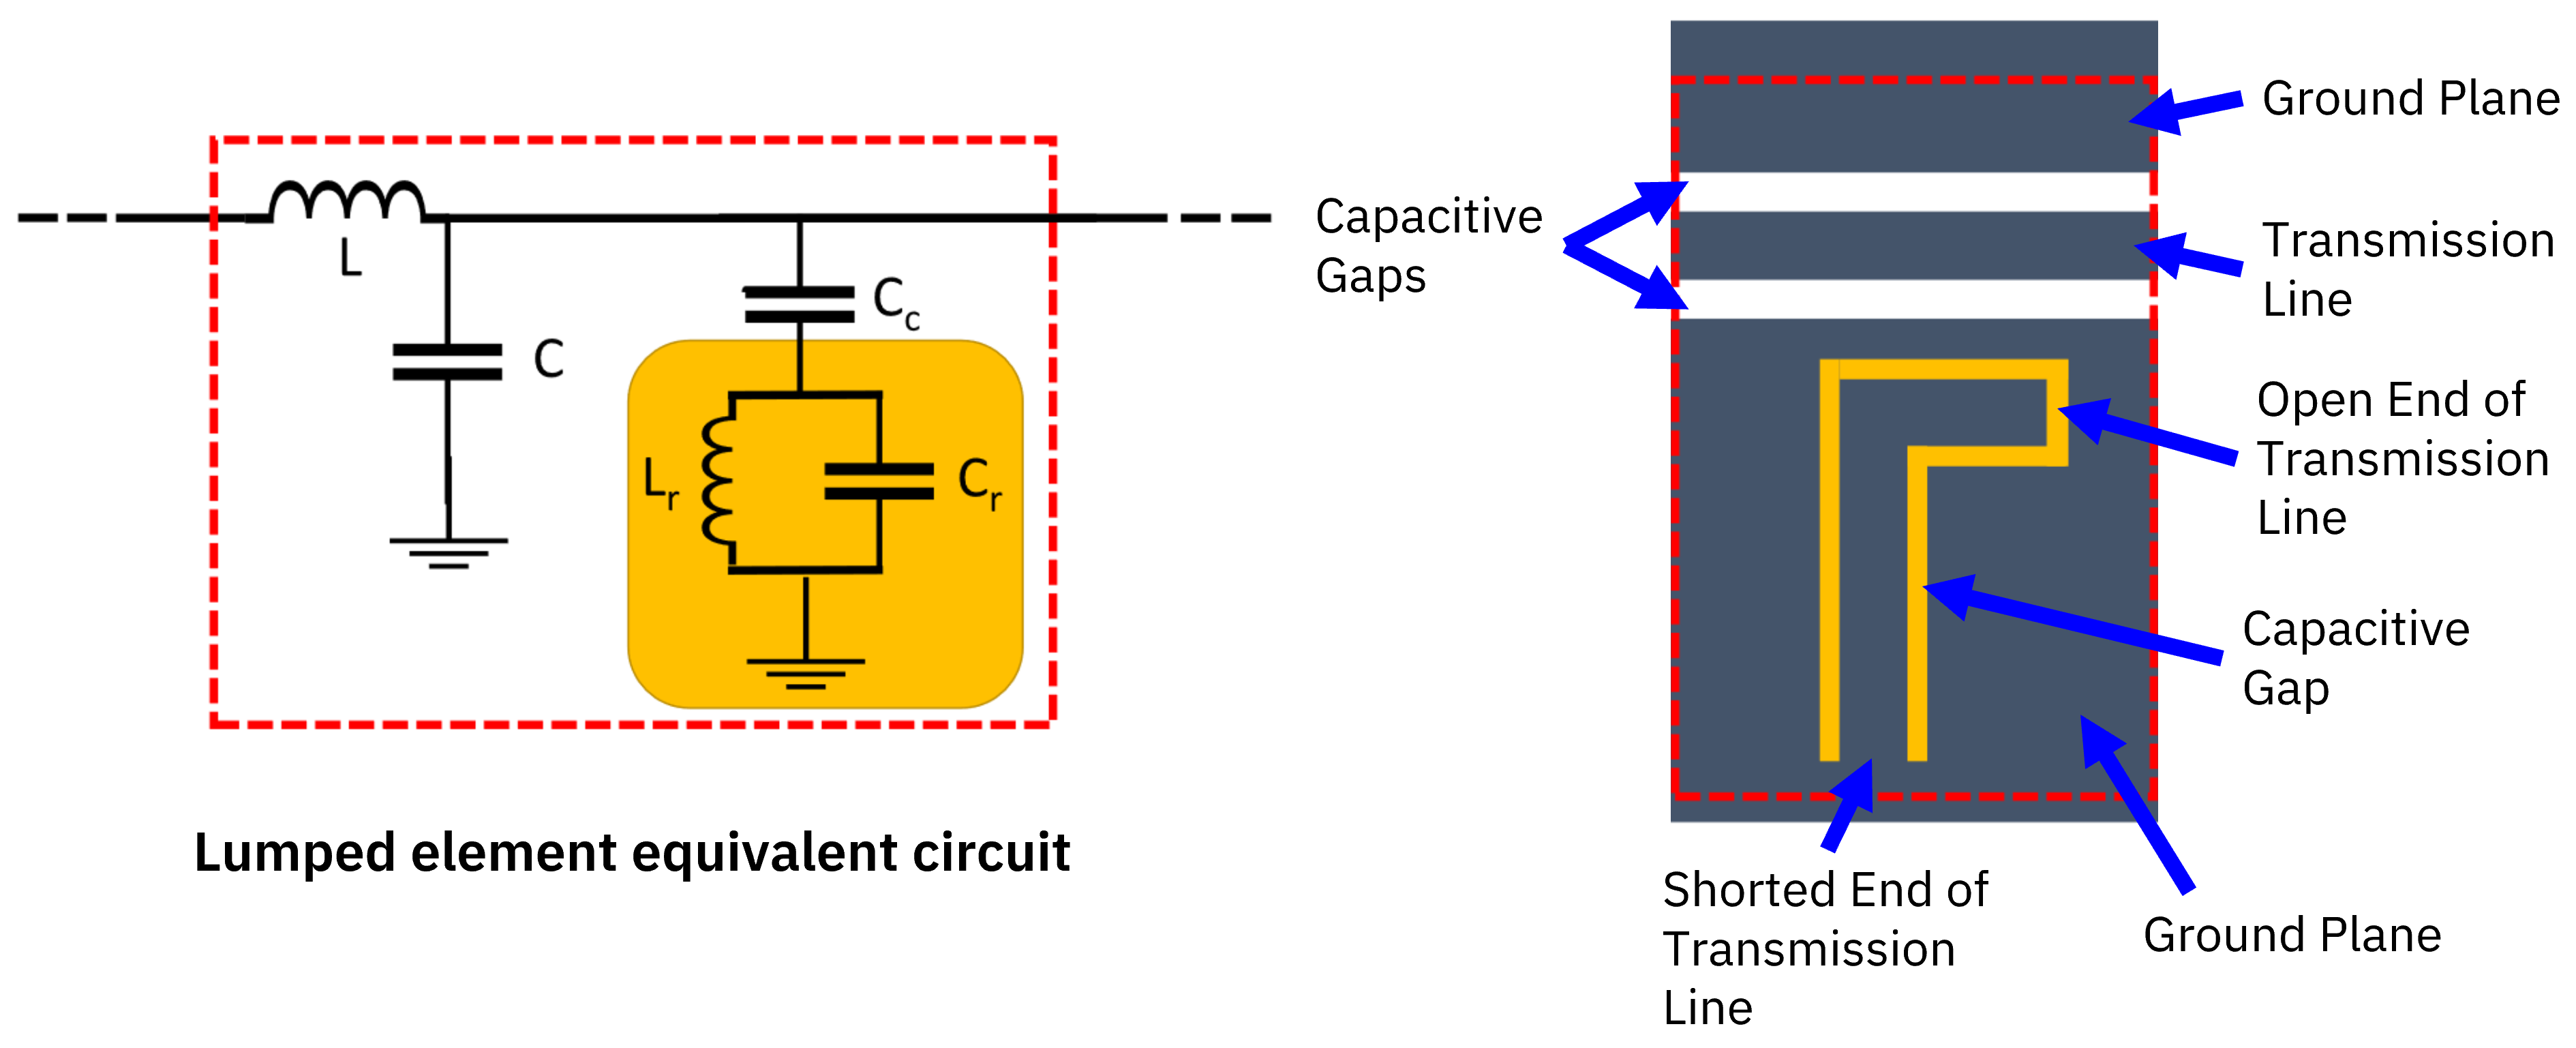

Adapted from Sweetnam et al., Supercond. Sci. Technol. 35 095011 (2022)

CuPy runtime available.
CuPy GPU backend, device = Tesla T4

Frequency summary:
 nominal_GHz  mean_GHz    std_MHz  p05_GHz  p50_GHz  p95_GHz  yield_percent
    4.594407  4.603696 188.667522 4.299995 4.599024 4.922626        53.7575

Tolerance sweep:
 tolerance_percent    std_MHz  yield_percent  p05_GHz  p95_GHz
               1.0  37.392717      99.976667 4.533715 4.656932
               2.0  75.226265      93.400000 4.474136 4.720472
               3.0 112.437470      77.996667 4.413907 4.784410
               5.0 188.895693      53.596667 4.297992 4.918975
               8.0 303.772199      35.173333 4.137665 5.136605
              10.0 381.303291      28.640000 4.027958 5.281786

Electrostatic solver summary:
                            backend      grid  iterations  converged  final_max_update_V  capacitance_proxy  energy_proxy  peak_field  mean_signal_field
CuPy GPU backend, device = Tesla T4 512 x 512        2700       True             0.00001           3.892422      1.946211    

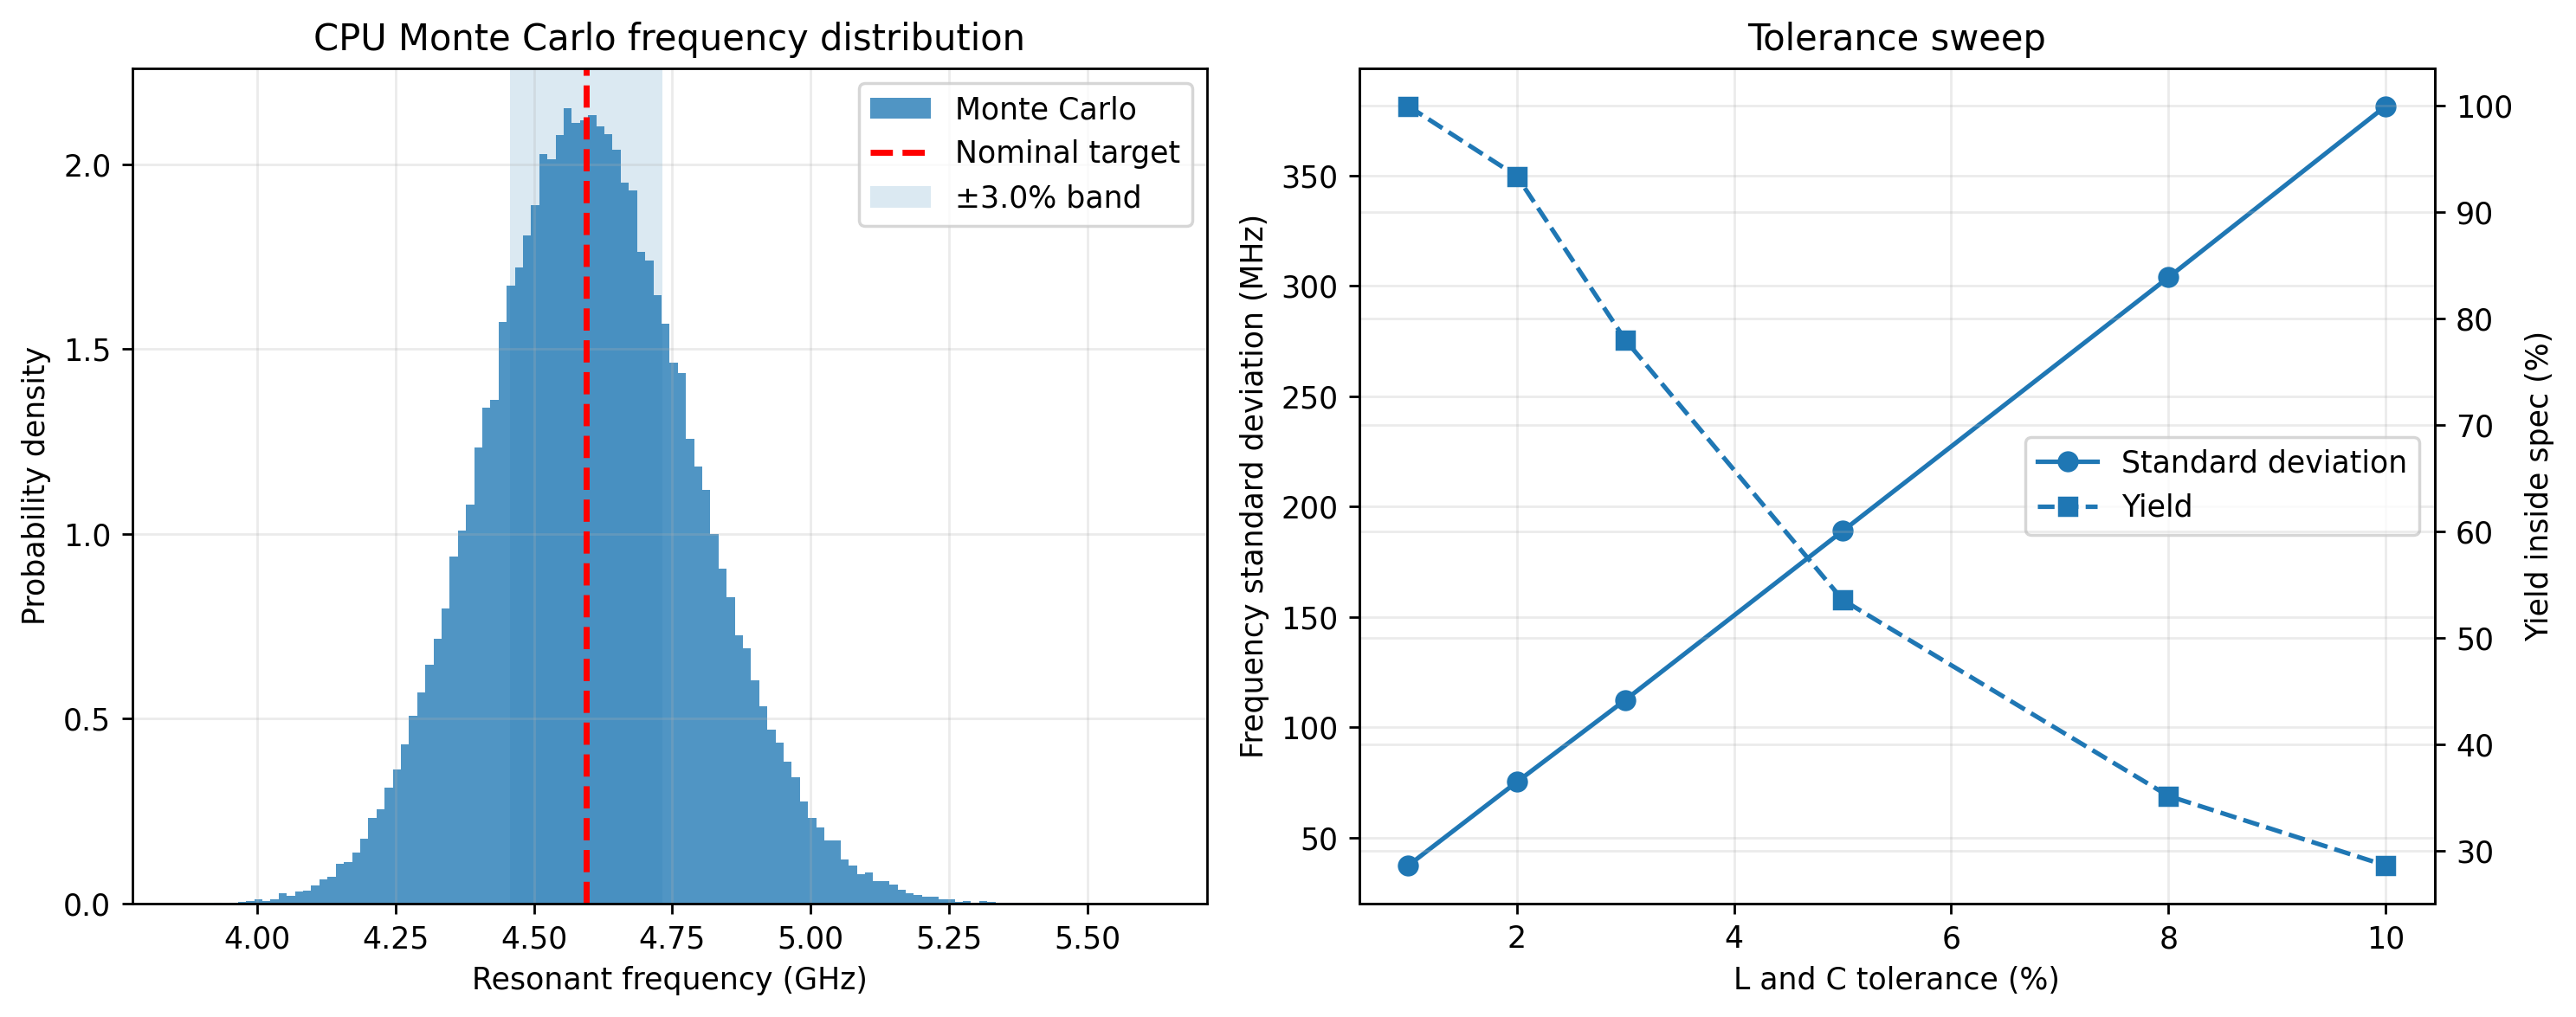

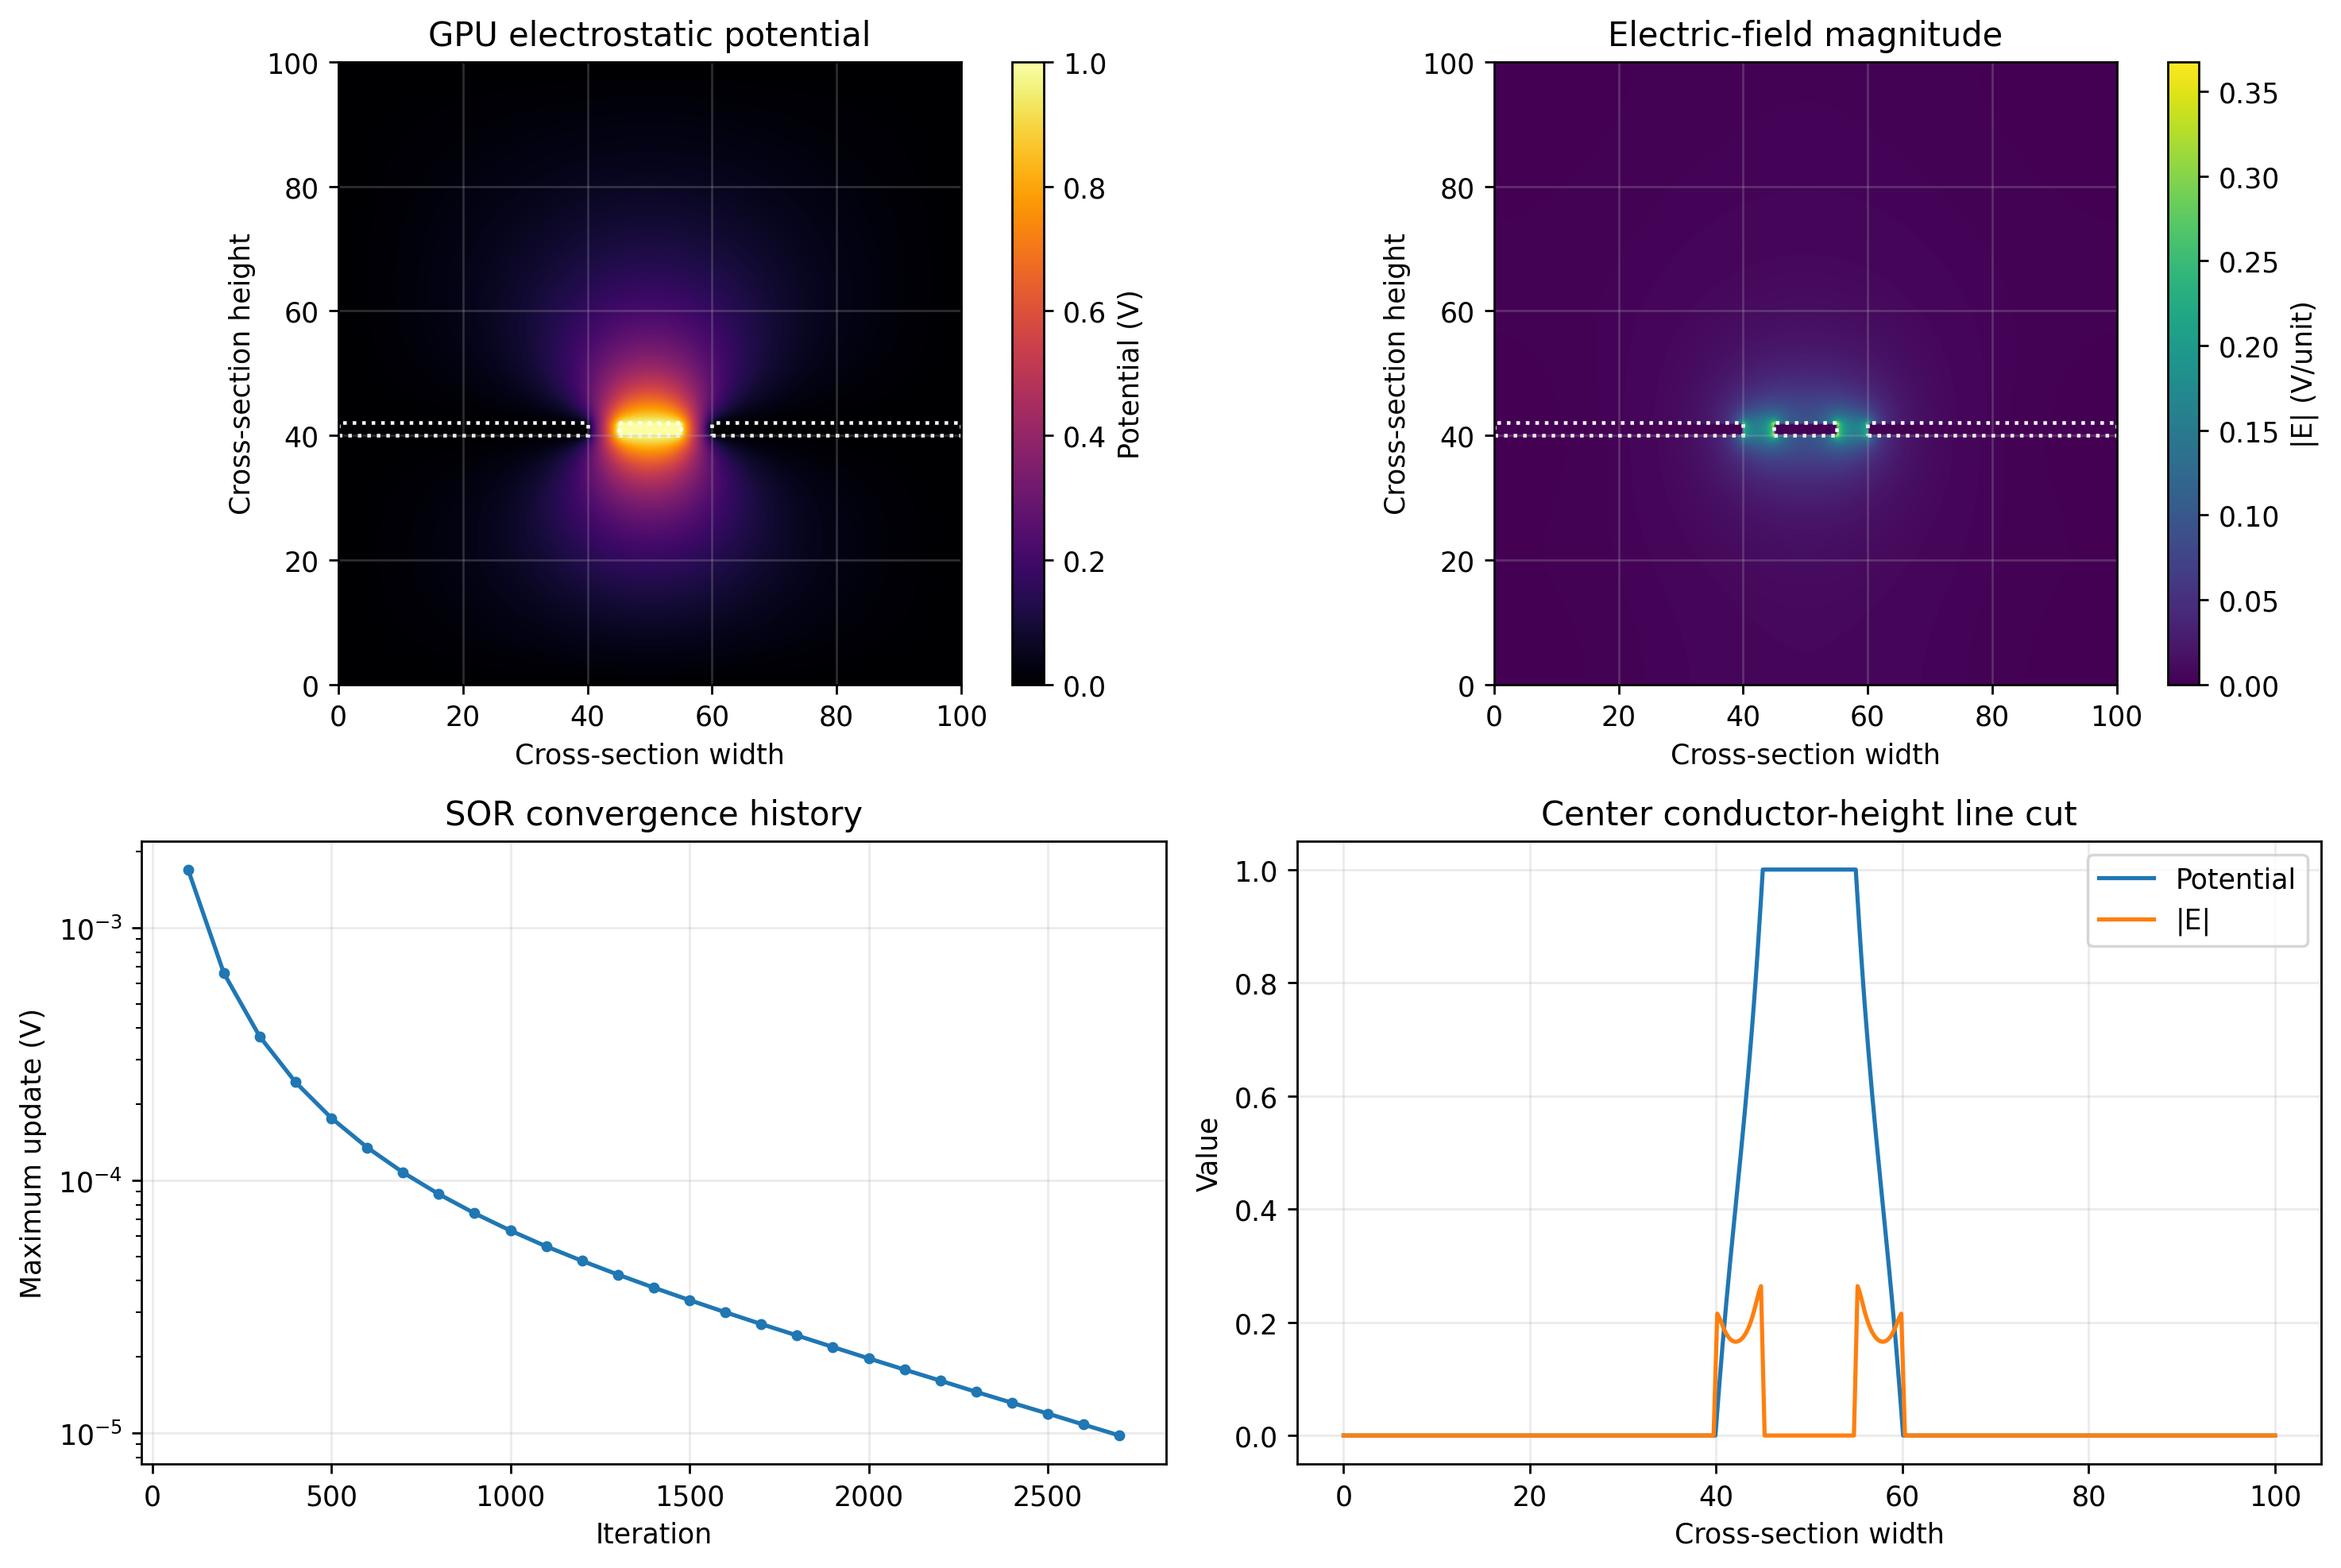

In [7]:
"""
CPU and GPU analysis for a superconducting CPW resonator.

!pip install -q uv
!uv pip install -q numpy pandas matplotlib cupy-cuda12x

The workflow couples a CPU Monte Carlo resonant-frequency analysis with a
CuPy-accelerated finite-difference electrostatic solver for a coplanar
waveguide cross section. It reports frequency statistics, yield against a
user-defined band, solver convergence, electric-field diagnostics, and a
capacitance proxy from electrostatic energy.
"""

from dataclasses import dataclass
from typing import Any

import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    import cupy as cp

    GPU_COUNT = cp.cuda.runtime.getDeviceCount()
    USING_CUPY = GPU_COUNT > 0
    CUPY_IMPORT_MESSAGE = "CuPy runtime available."
except Exception as cupy_error:
    cp = None
    GPU_COUNT = 0
    USING_CUPY = False
    CUPY_IMPORT_MESSAGE = f"CuPy fallback active: {cupy_error}"

XP: Any = cp if USING_CUPY else np


# =============================================================================
# CONTROL KNOBS
# =============================================================================

# Plot controls
MPL_DPI = 250
FIGURE_SIZE_FREQUENCY = (12.0, 4.8)
FIGURE_SIZE_FIELD = (12.0, 8.0)
FONT_SANS_SERIF = ("Tahoma", "DejaVu Sans")
POTENTIAL_CMAP = "inferno"
FIELD_CMAP = "viridis"

# Monte Carlo controls
RANDOM_SEED = 42
MC_SAMPLES = 120_000
NOMINAL_INDUCTANCE_H = 1.5e-9
NOMINAL_CAPACITANCE_F = 0.8e-12
INDUCTANCE_TOLERANCE = 0.05
CAPACITANCE_TOLERANCE = 0.05
LC_CORRELATION = 0.35
FREQUENCY_SPEC_FRACTION = 0.03
TOLERANCE_SWEEP = (0.01, 0.02, 0.03, 0.05, 0.08, 0.10)

# Finite-difference controls
GRID_RESOLUTION = 512
MAX_ITERATIONS = 30_000
MIN_ITERATIONS = 600
CHECK_EVERY = 100
SOR_OMEGA = 1.86
CONVERGENCE_TOLERANCE = 1.0e-5
FLOAT_DTYPE = "float32"

# Geometry controls in arbitrary cross-section units
DOMAIN_WIDTH = 100.0
DOMAIN_HEIGHT = 100.0
SIGNAL_WIDTH = 10.0
GAP_WIDTH = 5.0
TRACE_THICKNESS = 2.0
TRACE_Y_CENTER = 41.0
SIGNAL_VOLTAGE = 1.0
GROUND_VOLTAGE = 0.0
RELATIVE_PERMITTIVITY = 1.0


@dataclass(frozen=True)
class MonteCarloResult:
    """Container for resonant-frequency Monte Carlo outputs."""

    inductance_h: np.ndarray
    capacitance_f: np.ndarray
    frequency_hz: np.ndarray
    nominal_frequency_hz: float
    summary: pd.DataFrame
    sweep: pd.DataFrame


@dataclass(frozen=True)
class GeometryMasks:
    """Container for electrostatic fixed-potential masks."""

    x_axis: Any
    y_axis: Any
    fixed_mask: Any
    fixed_values: Any
    signal_mask: Any
    left_ground_mask: Any
    right_ground_mask: Any


@dataclass(frozen=True)
class FdmResult:
    """Container for finite-difference electrostatic solver outputs."""

    potential_v: np.ndarray
    x_axis: np.ndarray
    y_axis: np.ndarray
    residual_history: pd.DataFrame
    iterations: int
    converged: bool


@dataclass(frozen=True)
class FieldDiagnostics:
    """Container for derived electric-field and energy diagnostics."""

    electric_x: np.ndarray
    electric_y: np.ndarray
    electric_magnitude: np.ndarray
    energy_proxy: float
    capacitance_proxy: float
    peak_field: float
    mean_signal_field: float


def configure_plotting() -> None:
    """Configure Matplotlib for high-DPI Colab rendering."""

    mpl.rcParams["figure.dpi"] = MPL_DPI
    mpl.rcParams["savefig.dpi"] = MPL_DPI
    mpl.rcParams["font.family"] = "sans-serif"
    mpl.rcParams["font.sans-serif"] = list(FONT_SANS_SERIF)
    mpl.rcParams["axes.grid"] = True
    mpl.rcParams["grid.alpha"] = 0.25
    mpl.rcParams["axes.titlesize"] = 12
    mpl.rcParams["axes.labelsize"] = 10


def scalar_to_float(value: Any) -> float:
    """Convert a NumPy or CuPy scalar to a Python float."""

    if USING_CUPY:
        return float(cp.asnumpy(value).item())
    return float(np.asarray(value).item())


def to_numpy(array: Any) -> np.ndarray:
    """Convert a NumPy or CuPy array to a NumPy array."""

    if USING_CUPY:
        return cp.asnumpy(array)
    return np.asarray(array)


def trapezoid_integral(values: np.ndarray, dx: float, axis: int) -> np.ndarray:
    """Evaluate a trapezoidal integral with NumPy version compatibility."""

    if hasattr(np, "trapezoid"):
        return np.trapezoid(values, dx=dx, axis=axis)
    return np.trapz(values, dx=dx, axis=axis)


def get_backend_label() -> str:
    """Return a compact backend label for printed diagnostics."""

    if USING_CUPY:
        props = cp.cuda.runtime.getDeviceProperties(0)
        gpu_name = props.get("name", b"GPU")
        if isinstance(gpu_name, bytes):
            gpu_name = gpu_name.decode("utf-8")
        return f"CuPy GPU backend, device = {gpu_name}"
    return "NumPy CPU backend"


def generate_positive_lc_samples(
    samples: int,
    inductance_tolerance: float,
    capacitance_tolerance: float,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Generate correlated positive L and C samples using lognormal noise."""

    covariance = np.array(
        [[1.0, LC_CORRELATION], [LC_CORRELATION, 1.0]],
        dtype=np.float64,
    )
    normal_samples = rng.multivariate_normal(
        mean=np.zeros(2, dtype=np.float64),
        cov=covariance,
        size=samples,
    )

    sigma_l = np.sqrt(np.log1p(inductance_tolerance**2))
    sigma_c = np.sqrt(np.log1p(capacitance_tolerance**2))

    mu_l = np.log(NOMINAL_INDUCTANCE_H) - 0.5 * sigma_l**2
    mu_c = np.log(NOMINAL_CAPACITANCE_F) - 0.5 * sigma_c**2

    inductance_h = np.exp(mu_l + sigma_l * normal_samples[:, 0])
    capacitance_f = np.exp(mu_c + sigma_c * normal_samples[:, 1])

    return inductance_h, capacitance_f


def resonant_frequency(
    inductance_h: np.ndarray,
    capacitance_f: np.ndarray,
) -> np.ndarray:
    """Compute lumped LC resonant frequency in hertz."""

    return 1.0 / (2.0 * np.pi * np.sqrt(inductance_h * capacitance_f))


def build_frequency_summary(
    frequency_hz: np.ndarray,
    nominal_frequency_hz: float,
) -> pd.DataFrame:
    """Build a one-row summary table for the frequency distribution."""

    lower_spec = nominal_frequency_hz * (1.0 - FREQUENCY_SPEC_FRACTION)
    upper_spec = nominal_frequency_hz * (1.0 + FREQUENCY_SPEC_FRACTION)
    in_spec = (frequency_hz >= lower_spec) & (frequency_hz <= upper_spec)

    data = {
        "nominal_GHz": nominal_frequency_hz / 1.0e9,
        "mean_GHz": np.mean(frequency_hz) / 1.0e9,
        "std_MHz": np.std(frequency_hz) / 1.0e6,
        "p05_GHz": np.percentile(frequency_hz, 5.0) / 1.0e9,
        "p50_GHz": np.percentile(frequency_hz, 50.0) / 1.0e9,
        "p95_GHz": np.percentile(frequency_hz, 95.0) / 1.0e9,
        "yield_percent": 100.0 * np.mean(in_spec),
    }

    return pd.DataFrame([data])


def run_tolerance_sweep() -> pd.DataFrame:
    """Evaluate frequency spread and yield across fabrication tolerances."""

    rows = []
    nominal_frequency_hz = resonant_frequency(
        np.array([NOMINAL_INDUCTANCE_H]),
        np.array([NOMINAL_CAPACITANCE_F]),
    )[0]

    for sweep_index, tolerance in enumerate(TOLERANCE_SWEEP):
        rng = np.random.default_rng(RANDOM_SEED + 100 + sweep_index)
        inductance_h, capacitance_f = generate_positive_lc_samples(
            samples=max(MC_SAMPLES // 4, 20_000),
            inductance_tolerance=tolerance,
            capacitance_tolerance=tolerance,
            rng=rng,
        )
        frequency_hz = resonant_frequency(inductance_h, capacitance_f)
        summary = build_frequency_summary(frequency_hz, nominal_frequency_hz)

        rows.append(
            {
                "tolerance_percent": 100.0 * tolerance,
                "std_MHz": summary.loc[0, "std_MHz"],
                "yield_percent": summary.loc[0, "yield_percent"],
                "p05_GHz": summary.loc[0, "p05_GHz"],
                "p95_GHz": summary.loc[0, "p95_GHz"],
            }
        )

    return pd.DataFrame(rows)


def simulate_monte_carlo_frequency() -> MonteCarloResult:
    """Run the CPU Monte Carlo resonant-frequency analysis."""

    rng = np.random.default_rng(RANDOM_SEED)
    inductance_h, capacitance_f = generate_positive_lc_samples(
        samples=MC_SAMPLES,
        inductance_tolerance=INDUCTANCE_TOLERANCE,
        capacitance_tolerance=CAPACITANCE_TOLERANCE,
        rng=rng,
    )
    frequency_hz = resonant_frequency(inductance_h, capacitance_f)
    nominal_frequency_hz = resonant_frequency(
        np.array([NOMINAL_INDUCTANCE_H]),
        np.array([NOMINAL_CAPACITANCE_F]),
    )[0]

    return MonteCarloResult(
        inductance_h=inductance_h,
        capacitance_f=capacitance_f,
        frequency_hz=frequency_hz,
        nominal_frequency_hz=nominal_frequency_hz,
        summary=build_frequency_summary(frequency_hz, nominal_frequency_hz),
        sweep=run_tolerance_sweep(),
    )


def build_geometry_masks(xp: Any) -> GeometryMasks:
    """Build fixed-potential masks for the CPW-like cross section."""

    dtype = xp.float32 if FLOAT_DTYPE == "float32" else xp.float64
    shape = (GRID_RESOLUTION, GRID_RESOLUTION)

    x_axis = xp.linspace(0.0, DOMAIN_WIDTH, GRID_RESOLUTION, dtype=dtype)
    y_axis = xp.linspace(0.0, DOMAIN_HEIGHT, GRID_RESOLUTION, dtype=dtype)
    xx, yy = xp.meshgrid(x_axis, y_axis)

    signal_x_min = 0.5 * DOMAIN_WIDTH - 0.5 * SIGNAL_WIDTH
    signal_x_max = 0.5 * DOMAIN_WIDTH + 0.5 * SIGNAL_WIDTH
    band_y_min = TRACE_Y_CENTER - 0.5 * TRACE_THICKNESS
    band_y_max = TRACE_Y_CENTER + 0.5 * TRACE_THICKNESS

    conductor_band = (yy >= band_y_min) & (yy <= band_y_max)
    signal_mask = (
        conductor_band
        & (xx >= signal_x_min)
        & (xx <= signal_x_max)
    )
    left_ground_mask = conductor_band & (xx <= signal_x_min - GAP_WIDTH)
    right_ground_mask = conductor_band & (xx >= signal_x_max + GAP_WIDTH)

    edge_mask = xp.zeros(shape, dtype=xp.bool_)
    edge_mask[0, :] = True
    edge_mask[-1, :] = True
    edge_mask[:, 0] = True
    edge_mask[:, -1] = True

    fixed_mask = signal_mask | left_ground_mask | right_ground_mask | edge_mask
    fixed_values = xp.full(shape, GROUND_VOLTAGE, dtype=dtype)
    fixed_values = xp.where(signal_mask, SIGNAL_VOLTAGE, fixed_values)

    return GeometryMasks(
        x_axis=x_axis,
        y_axis=y_axis,
        fixed_mask=fixed_mask,
        fixed_values=fixed_values,
        signal_mask=signal_mask,
        left_ground_mask=left_ground_mask,
        right_ground_mask=right_ground_mask,
    )


def solve_electrostatic_potential() -> FdmResult:
    """Solve the electrostatic potential using red-black SOR relaxation."""

    xp = XP
    dtype = xp.float32 if FLOAT_DTYPE == "float32" else xp.float64
    masks = build_geometry_masks(xp)

    potential = xp.array(masks.fixed_values, dtype=dtype)
    free_mask = ~masks.fixed_mask

    row_index, column_index = xp.indices(potential.shape)
    red_free = ((row_index + column_index) % 2 == 0) & free_mask
    black_free = ((row_index + column_index) % 2 == 1) & free_mask

    residual_rows = []
    converged = False
    completed_iteration = 0

    for iteration in range(1, MAX_ITERATIONS + 1):
        delta_current = xp.asarray(0.0, dtype=dtype)

        for color_mask in (red_free, black_free):
            neighbor_average = 0.25 * (
                xp.roll(potential, 1, axis=0)
                + xp.roll(potential, -1, axis=0)
                + xp.roll(potential, 1, axis=1)
                + xp.roll(potential, -1, axis=1)
            )
            proposed = (
                (1.0 - SOR_OMEGA) * potential
                + SOR_OMEGA * neighbor_average
            )
            delta_array = xp.abs(proposed[color_mask] - potential[color_mask])
            delta_current = xp.maximum(delta_current, xp.max(delta_array))
            potential = xp.where(color_mask, proposed, potential)
            potential = xp.where(masks.fixed_mask, masks.fixed_values, potential)

        completed_iteration = iteration

        if iteration % CHECK_EVERY == 0:
            residual = scalar_to_float(delta_current)
            residual_rows.append(
                {
                    "iteration": iteration,
                    "max_update_v": residual,
                }
            )
            if (iteration >= MIN_ITERATIONS) & (
                residual <= CONVERGENCE_TOLERANCE
            ):
                converged = True
                break

    residual_history = pd.DataFrame(residual_rows)

    return FdmResult(
        potential_v=to_numpy(potential),
        x_axis=to_numpy(masks.x_axis),
        y_axis=to_numpy(masks.y_axis),
        residual_history=residual_history,
        iterations=completed_iteration,
        converged=converged,
    )


def compute_field_diagnostics(fdm_result: FdmResult) -> FieldDiagnostics:
    """Compute electric field, energy, and capacitance-proxy diagnostics."""

    dx = DOMAIN_WIDTH / (GRID_RESOLUTION - 1)
    dy = DOMAIN_HEIGHT / (GRID_RESOLUTION - 1)

    d_v_dy, d_v_dx = np.gradient(fdm_result.potential_v, dy, dx)
    electric_x = -d_v_dx
    electric_y = -d_v_dy
    electric_magnitude = np.sqrt(electric_x**2 + electric_y**2)

    energy_density = 0.5 * RELATIVE_PERMITTIVITY * electric_magnitude**2
    energy_x = trapezoid_integral(energy_density, dx=dx, axis=1)
    energy_proxy = float(trapezoid_integral(energy_x, dx=dy, axis=0))
    capacitance_proxy = 2.0 * energy_proxy / SIGNAL_VOLTAGE**2

    signal_band = (
        (fdm_result.y_axis >= TRACE_Y_CENTER - TRACE_THICKNESS)
        & (fdm_result.y_axis <= TRACE_Y_CENTER + TRACE_THICKNESS)
    )
    signal_field_slice = electric_magnitude[signal_band, :]

    return FieldDiagnostics(
        electric_x=electric_x,
        electric_y=electric_y,
        electric_magnitude=electric_magnitude,
        energy_proxy=energy_proxy,
        capacitance_proxy=capacitance_proxy,
        peak_field=float(np.max(electric_magnitude)),
        mean_signal_field=float(np.mean(signal_field_slice)),
    )


def build_fdm_summary(
    fdm_result: FdmResult,
    diagnostics: FieldDiagnostics,
) -> pd.DataFrame:
    """Build a one-row table of electrostatic solver diagnostics."""

    if fdm_result.residual_history.empty:
        final_residual = np.nan
    else:
        final_residual = fdm_result.residual_history["max_update_v"].iloc[-1]

    data = {
        "backend": get_backend_label(),
        "grid": f"{GRID_RESOLUTION} x {GRID_RESOLUTION}",
        "iterations": fdm_result.iterations,
        "converged": fdm_result.converged,
        "final_max_update_V": final_residual,
        "capacitance_proxy": diagnostics.capacitance_proxy,
        "energy_proxy": diagnostics.energy_proxy,
        "peak_field": diagnostics.peak_field,
        "mean_signal_field": diagnostics.mean_signal_field,
    }

    return pd.DataFrame([data])


def add_geometry_overlay(ax: plt.Axes) -> None:
    """Draw the CPW signal and ground conductor outlines."""

    signal_x_min = 0.5 * DOMAIN_WIDTH - 0.5 * SIGNAL_WIDTH
    signal_y_min = TRACE_Y_CENTER - 0.5 * TRACE_THICKNESS
    ground_left_width = signal_x_min - GAP_WIDTH
    ground_right_x = signal_x_min + SIGNAL_WIDTH + GAP_WIDTH
    ground_right_width = DOMAIN_WIDTH - ground_right_x

    patch_style = {
        "linewidth": 1.3,
        "edgecolor": "white",
        "facecolor": "none",
        "linestyle": ":",
    }

    rectangles = (
        patches.Rectangle(
            (signal_x_min, signal_y_min),
            SIGNAL_WIDTH,
            TRACE_THICKNESS,
            **patch_style,
        ),
        patches.Rectangle(
            (0.0, signal_y_min),
            ground_left_width,
            TRACE_THICKNESS,
            **patch_style,
        ),
        patches.Rectangle(
            (ground_right_x, signal_y_min),
            ground_right_width,
            TRACE_THICKNESS,
            **patch_style,
        ),
    )

    for rectangle in rectangles:
        ax.add_patch(rectangle)


def plot_frequency_results(result: MonteCarloResult) -> None:
    """Render frequency histogram and tolerance-sweep diagnostics."""

    lower_spec = result.nominal_frequency_hz * (1.0 - FREQUENCY_SPEC_FRACTION)
    upper_spec = result.nominal_frequency_hz * (1.0 + FREQUENCY_SPEC_FRACTION)

    fig, axes = plt.subplots(1, 2, figsize=FIGURE_SIZE_FREQUENCY)

    axes[0].hist(
        result.frequency_hz / 1.0e9,
        bins=120,
        density=True,
        alpha=0.78,
        label="Monte Carlo",
    )
    axes[0].axvline(
        result.nominal_frequency_hz / 1.0e9,
        color="red",
        linestyle="--",
        linewidth=2.0,
        label="Nominal target",
    )
    axes[0].axvspan(
        lower_spec / 1.0e9,
        upper_spec / 1.0e9,
        alpha=0.16,
        label=f"±{100.0 * FREQUENCY_SPEC_FRACTION:.1f}% band",
    )
    axes[0].set_title("CPU Monte Carlo frequency distribution")
    axes[0].set_xlabel("Resonant frequency (GHz)")
    axes[0].set_ylabel("Probability density")
    axes[0].legend(loc="upper right")

    axes[1].plot(
        result.sweep["tolerance_percent"],
        result.sweep["std_MHz"],
        marker="o",
        label="Standard deviation",
    )
    axes[1].set_title("Tolerance sweep")
    axes[1].set_xlabel("L and C tolerance (%)")
    axes[1].set_ylabel("Frequency standard deviation (MHz)")

    sweep_yield_axis = axes[1].twinx()
    sweep_yield_axis.plot(
        result.sweep["tolerance_percent"],
        result.sweep["yield_percent"],
        marker="s",
        linestyle="--",
        label="Yield",
    )
    sweep_yield_axis.set_ylabel("Yield inside spec (%)")

    lines_0, labels_0 = axes[1].get_legend_handles_labels()
    lines_1, labels_1 = sweep_yield_axis.get_legend_handles_labels()
    axes[1].legend(lines_0 + lines_1, labels_0 + labels_1, loc="center right")

    fig.tight_layout()
    plt.show()


def plot_field_results(
    fdm_result: FdmResult,
    diagnostics: FieldDiagnostics,
) -> None:
    """Render potential, field magnitude, residual, and centerline profiles."""

    extent = [0.0, DOMAIN_WIDTH, 0.0, DOMAIN_HEIGHT]
    fig, axes = plt.subplots(2, 2, figsize=FIGURE_SIZE_FIELD)

    potential_image = axes[0, 0].imshow(
        fdm_result.potential_v,
        origin="lower",
        extent=extent,
        cmap=POTENTIAL_CMAP,
        vmin=GROUND_VOLTAGE,
        vmax=SIGNAL_VOLTAGE,
        aspect="equal",
    )
    add_geometry_overlay(axes[0, 0])
    axes[0, 0].set_title("GPU electrostatic potential")
    axes[0, 0].set_xlabel("Cross-section width")
    axes[0, 0].set_ylabel("Cross-section height")
    fig.colorbar(potential_image, ax=axes[0, 0], label="Potential (V)")

    field_image = axes[0, 1].imshow(
        diagnostics.electric_magnitude,
        origin="lower",
        extent=extent,
        cmap=FIELD_CMAP,
        aspect="equal",
    )
    add_geometry_overlay(axes[0, 1])
    axes[0, 1].set_title("Electric-field magnitude")
    axes[0, 1].set_xlabel("Cross-section width")
    axes[0, 1].set_ylabel("Cross-section height")
    fig.colorbar(field_image, ax=axes[0, 1], label="|E| (V/unit)")

    if fdm_result.residual_history.empty:
        axes[1, 0].text(
            0.5,
            0.5,
            "Residual history is empty.",
            ha="center",
            va="center",
            transform=axes[1, 0].transAxes,
        )
    else:
        axes[1, 0].semilogy(
            fdm_result.residual_history["iteration"],
            fdm_result.residual_history["max_update_v"],
            marker=".",
        )
    axes[1, 0].set_title("SOR convergence history")
    axes[1, 0].set_xlabel("Iteration")
    axes[1, 0].set_ylabel("Maximum update (V)")

    center_index = int(np.argmin(np.abs(fdm_result.y_axis - TRACE_Y_CENTER)))
    axes[1, 1].plot(
        fdm_result.x_axis,
        fdm_result.potential_v[center_index, :],
        label="Potential",
    )
    axes[1, 1].plot(
        fdm_result.x_axis,
        diagnostics.electric_magnitude[center_index, :],
        label="|E|",
    )
    axes[1, 1].set_title("Center conductor-height line cut")
    axes[1, 1].set_xlabel("Cross-section width")
    axes[1, 1].set_ylabel("Value")
    axes[1, 1].legend()

    fig.tight_layout()
    plt.show()


def main() -> tuple[MonteCarloResult, FdmResult, FieldDiagnostics]:
    """Run the complete CPU and GPU resonator analysis."""

    configure_plotting()

    print(CUPY_IMPORT_MESSAGE)
    print(get_backend_label())

    monte_carlo_result = simulate_monte_carlo_frequency()
    print("\nFrequency summary:")
    print(monte_carlo_result.summary.to_string(index=False))
    print("\nTolerance sweep:")
    print(monte_carlo_result.sweep.to_string(index=False))

    fdm_result = solve_electrostatic_potential()
    diagnostics = compute_field_diagnostics(fdm_result)
    fdm_summary = build_fdm_summary(fdm_result, diagnostics)
    print("\nElectrostatic solver summary:")
    print(fdm_summary.to_string(index=False))

    plot_frequency_results(monte_carlo_result)
    plot_field_results(fdm_result, diagnostics)

    return monte_carlo_result, fdm_result, diagnostics


if __name__ == "__main__":
    results = main()